In [6]:
import os

os.makedirs("../data/processed", exist_ok=True)

maize_df.to_csv("../data/processed/maize_only.csv", index=False)
print(f"Saved {len(maize_df)} Maize rows to data/processed/maize_only.csv")

Saved 166824 Maize rows to data/processed/maize_only.csv


In [2]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/crop_yield.csv"

df = pd.read_csv(DATA_PATH)
maize_df = df[df["Crop"] == "Maize"].reset_index(drop=True)
print(f"Maize rows: {len(maize_df)}")
maize_df.head()

Maize rows: 166824


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,South,Clay,Maize,888.207630,39.945509,True,False,Rainy,76,7.173037
1,East,Chalky,Maize,170.814456,29.116377,False,True,Sunny,133,2.332255
2,South,Silt,Maize,259.418125,17.261892,False,False,Sunny,110,2.338541
3,East,Silt,Maize,609.798764,38.265851,True,False,Cloudy,127,5.113588
4,East,Clay,Maize,599.875493,19.909292,True,False,Cloudy,63,4.696425


In [3]:
negative_yield_count = (maize_df["Yield_tons_per_hectare"] < 0).sum()
negative_pct = 100 * negative_yield_count / len(maize_df)

print(f"Rows with negative yield: {negative_yield_count} ({negative_pct:.3f}% of dataset)")
print(f"Min yield value: {maize_df['Yield_tons_per_hectare'].min():.4f}")

# DECISION: negative yield values are left unmodified.
# Rationale: this is a synthetic dataset (see EDA notebook for evidence —
# uniform feature distributions, near-zero correlation for most features,
# physically impossible negative yields). The negative values are an
# artifact of unclamped noise in the data-generating process, not a data
# entry error. Clipping to 0 would silently alter ground truth based on an
# unverified assumption about that generating process. Documented here as
# a known limitation rather than corrected.

Rows with negative yield: 39 (0.023% of dataset)
Min yield value: -0.8752


In [4]:
# Crop column is now constant ("Maize") across all rows post-filter — no
# predictive value, safe to drop
model_df = maize_df.drop(columns=["Crop"])

X = model_df.drop(columns=["Yield_tons_per_hectare"])
y = model_df["Yield_tons_per_hectare"]

print(f"Feature columns: {list(X.columns)}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Feature columns: ['Region', 'Soil_Type', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Days_to_Harvest']
X shape: (166824, 8), y shape: (166824,)


In [4]:
categorical_cols = ["Region", "Soil_Type", "Weather_Condition"]
boolean_cols = ["Fertilizer_Used", "Irrigation_Used"]

# One-hot encode nominal categoricals — no ordinal relationship between
# e.g. "Clay" and "Loam", so label encoding would wrongly imply an order
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

# Cast booleans to 0/1 explicitly (pandas bool -> XGBoost prefers numeric)
for col in boolean_cols:
    X_encoded[col] = X_encoded[col].astype(int)

print(f"Encoded feature count: {X_encoded.shape[1]}")
print(f"Columns: {list(X_encoded.columns)}")
X_encoded.head()

Encoded feature count: 18
Columns: ['Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Days_to_Harvest', 'Region_East', 'Region_North', 'Region_South', 'Region_West', 'Soil_Type_Chalky', 'Soil_Type_Clay', 'Soil_Type_Loam', 'Soil_Type_Peaty', 'Soil_Type_Sandy', 'Soil_Type_Silt', 'Weather_Condition_Cloudy', 'Weather_Condition_Rainy', 'Weather_Condition_Sunny']


,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Region_East,Region_North,Region_South,Region_West,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny
0,888.207630,39.945509,1,0,76,False,False,True,False,False,True,False,False,False,False,False,True,False
1,170.814456,29.116377,0,1,133,True,False,False,False,True,False,False,False,False,False,False,False,True
2,259.418125,17.261892,0,0,110,False,False,True,False,False,False,False,False,False,True,False,False,True
3,609.798764,38.265851,1,0,127,True,False,False,False,False,False,False,False,False,True,True,False,False
4,599.875493,19.909292,1,0,63,True,False,False,False,False,True,False,False,False,False,True,False,False


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

NameError: name 'X_encoded' is not defined

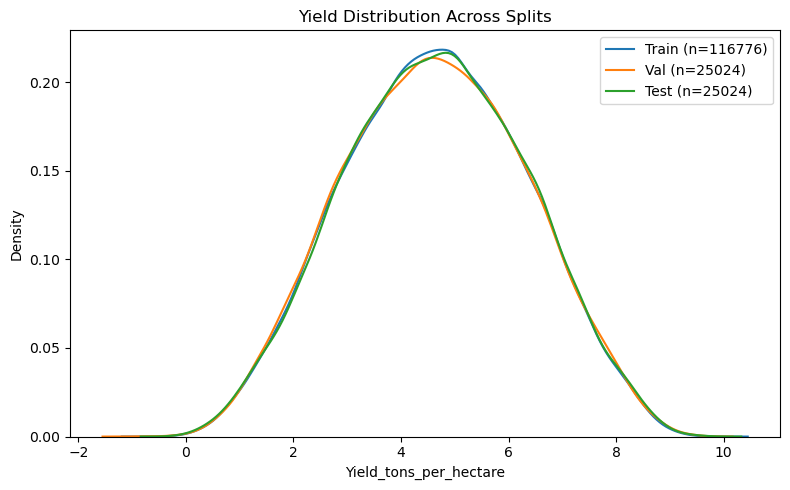

Mean yield by split:
  Train: 4.6402
  Val:   4.6348
  Test:  4.6537


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(y_train, label=f"Train (n={len(y_train)})", ax=ax)
sns.kdeplot(y_val, label=f"Val (n={len(y_val)})", ax=ax)
sns.kdeplot(y_test, label=f"Test (n={len(y_test)})", ax=ax)
ax.set_title("Yield Distribution Across Splits")
ax.legend()
plt.tight_layout()
plt.show()

print("Mean yield by split:")
print(f"  Train: {y_train.mean():.4f}")
print(f"  Val:   {y_val.mean():.4f}")
print(f"  Test:  {y_test.mean():.4f}")

In [7]:
import os

os.makedirs("../data/processed", exist_ok=True)

X_train.to_csv("../data/processed/X_train.csv", index=False)
X_val.to_csv("../data/processed/X_val.csv", index=False)
X_test.to_csv("../data/processed/X_test.csv", index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_val.to_csv("../data/processed/y_val.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

print("Saved processed splits to data/processed/")

Saved processed splits to data/processed/
